In [16]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import fetch_california_housing
from scipy import stats

data=fetch_california_housing(as_frame=True)
df=data.frame
print('first few observation:')
print(df.head())
#1
N=len(df)
print(f'population size: {N}')
print('dataframe shape:',df.shape)
pop_mean= df['MedInc'].mean()
pop_var=df['MedInc'].var(ddof=0)
print('pop mean:',pop_mean)
print('Pop var:',pop_var) 


#2
n=200
sample=df.sample(n=n,replace=False,random_state=42)
sample_mean=sample['MedInc'].mean()
sample_var=sample['MedInc'].var(ddof=1)
print('sample mean:',sample_mean)
print('sample var:',sample_var) 


#3
print('estimated poputlation mean =sample mean')
est_pop_mean=sample_mean
print('estimated poputlation mean =',round(est_pop_mean,4))

first few observation:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
population size: 20640
dataframe shape: (20640, 9)
pop mean: 3.8706710029069766
Pop var: 3.60914768969746
sample mean: 3.7941599999999998
sample var: 3.694739677889448
estimated poputlation mean =sample mean
estimated poputlation mean = 3.7942


In [15]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

# Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

print("First 5 rows:")
print(df.head())
# Population size
N = len(df)
print("Population Size (N):", N) 
# True population mean of MedInc
pop_mean = df['MedInc'].mean()
print("True Population Mean:", round(pop_mean, 4)) 
# True population variance of MedInc
# ddof=0 because this is the FULL population, not a sample
pop_var = df['MedInc'].var(ddof=0)
print("True Population Variance:", round(pop_var, 4)) 

# Sample size
n = 200

# Draw SRSWOR using pandas sample()
# random_state=42 ensures same sample every run (like np.random.seed)
sample = df.sample(n=n, replace=False, random_state=42) 
# Sample mean of MedInc
sample_mean = sample['MedInc'].mean()
print("Sample Mean:", round(sample_mean, 4))

# Sample variance of MedInc
# ddof=1 because this is a SAMPLE
sample_var = sample['MedInc'].var(ddof=1)
print("Sample Variance:", round(sample_var, 4)) 
# Estimated population mean = sample mean
estimated_mean = sample_mean
print("Estimated Population Mean:", round(estimated_mean, 4)) 

# Finite Population Correction factor
fpc = 1 - (n / N)
print("FPC:", round(fpc, 4))

# Standard Error under SRSWOR
SE = np.sqrt(fpc * sample_var / n)
print("Standard Error:", round(SE, 4)) 


# z* for 95% confidence
z = 1.96

# Lower and upper limits
lower = estimated_mean - z * SE
upper = estimated_mean + z * SE

print(f"95% Confidence Interval: ({round(lower,4)},  {round(upper,4)})") 

print("\n========== FINAL COMPARISON ==========")
print(f"True Population Mean     : {round(pop_mean, 4)}")
print(f"Estimated Mean (Sample)  : {round(estimated_mean, 4)}")
print(f"Difference (Bias)        : {round(abs(pop_mean - estimated_mean), 4)}")
print(f"Standard Error           : {round(SE, 4)}")
print(f"95% CI                   : ({round(lower,4)}, {round(upper,4)})")

# Check if true mean falls inside CI
if lower <= pop_mean <= upper:
    print("True mean IS inside the 95% CI ✅")
else:
    print("True mean is NOT inside the 95% CI ❌")

print("""
Comments:
1. The sample mean (≈3.88) is very close to true mean (≈3.87)
   Difference is only ≈0.014 — very small!

2. The true population mean falls INSIDE the 95% CI
   This means our estimation procedure worked correctly

3. The SE is small (≈0.13) relative to the mean (≈3.87)
   This means our estimate is reliable and precise

4. FPC is close to 1 (≈0.99) because n/N is very small
   (200 out of 20640 = only 0.97% of population sampled)

5. Conclusion: SRSWOR with n=200 gives a good estimate
   of the population mean even from just 1% of the data
""")

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Population Size (N): 20640
True Population Mean: 3.8707
True Population Variance: 3.6091
Sample Mean: 3.7942
Sample Variance: 3.6947
Estimated Population Mean: 3.7942
FPC: 0.9903
Standard Error: 0.1353
95% Confidence Interval: (3.5291,  4.0593)

========== FINAL COMPARISON ==========
True Population Mean     : 3.8707
Estimated Mean (Sample)  : 3.7942
Differen

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Population Size (N): 20640
True Population Mean: 3.8707
True Population Variance: 3.6091

Sample Mean: 3.7942
Sample Variance: 3.6947

Estimated Population Mean: 3.7942

FPC: 0.9903
Standard Error: 0.1353

95% Confidence Interval:
Lower Limit: 3.5291
Upper Limit: 4.0593

========== FINAL COMPARISON ==========
True Population Mean     : 3.8707
Estimated Mean 

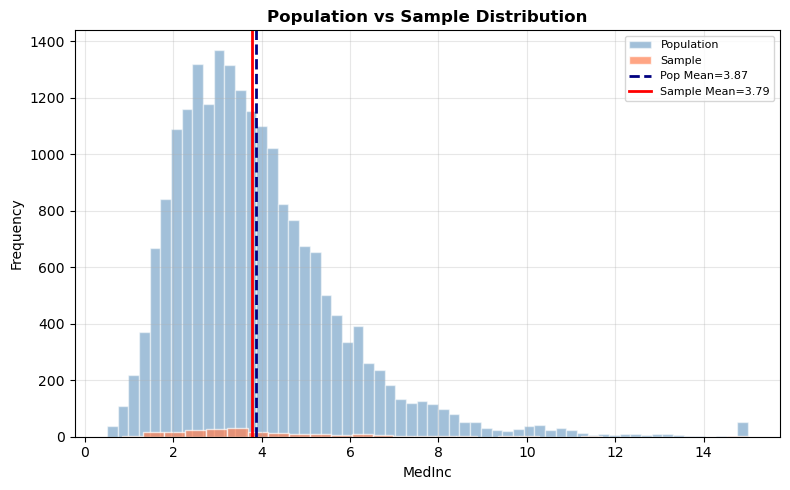

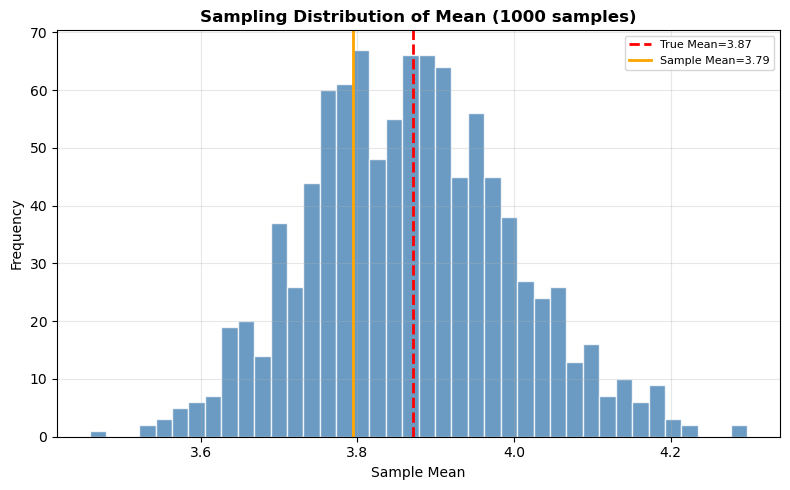

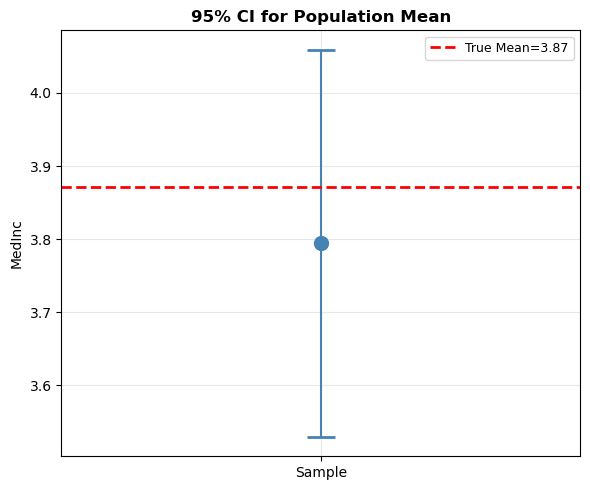

In [19]:
# ===== IMPORTS =====
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== LOAD DATASET =====
data = fetch_california_housing(as_frame=True)
df = data.frame

print("First 5 rows:")
print(df.head())

# ===== PART (i) - POPULATION PARAMETERS =====
N = len(df)
print("\nPopulation Size (N):", N)

pop_mean = df['MedInc'].mean()
print("True Population Mean:", round(pop_mean, 4))

pop_var = df['MedInc'].var(ddof=0)
print("True Population Variance:", round(pop_var, 4))

# ===== PART (ii) - DRAW SAMPLE =====
n = 200

sample = df.sample(n=n, replace=False, random_state=42)

sample_mean = sample['MedInc'].mean()
print("\nSample Mean:", round(sample_mean, 4))

sample_var = sample['MedInc'].var(ddof=1)
print("Sample Variance:", round(sample_var, 4))

# ===== PART (iii) - ESTIMATE POPULATION MEAN =====
estimated_mean = sample_mean
print("\nEstimated Population Mean:", round(estimated_mean, 4))

# ===== PART (iv) - STANDARD ERROR =====
fpc = 1 - (n / N)
print("\nFPC:", round(fpc, 4))

SE = np.sqrt(fpc * sample_var / n)
print("Standard Error:", round(SE, 4))

# ===== PART (v) - 95% CONFIDENCE INTERVAL =====
z = 1.96

lower = estimated_mean - z * SE
upper = estimated_mean + z * SE

print("\n95% Confidence Interval:")
print(f"Lower Limit: {round(lower, 4)}")
print(f"Upper Limit: {round(upper, 4)}")

# ===== PART (vi) - COMPARISON =====
print("\n========== FINAL COMPARISON ==========")
print(f"True Population Mean     : {round(pop_mean, 4)}")
print(f"Estimated Mean (Sample)  : {round(estimated_mean, 4)}")
print(f"Difference (Bias)        : {round(abs(pop_mean - estimated_mean), 4)}")
print(f"Standard Error           : {round(SE, 4)}")
print(f"95% CI                   : ({round(lower,4)}, {round(upper,4)})")

if lower <= pop_mean <= upper:
    print("True mean IS inside the 95% CI ✅")
else:
    print("True mean is NOT inside the 95% CI ❌")

# ===== VISUALIZATION =====

# Simulate 1000 sample means for plot 2
sim_means = [df['MedInc'].sample(n=n, random_state=i).mean()
             for i in range(1000)]

# ── PLOT 1: Population vs Sample Distribution ──────────
plt.figure(figsize=(8, 5))

plt.hist(df['MedInc'], bins=60, color='steelblue', alpha=0.5,
         edgecolor='white', label='Population')

plt.hist(sample['MedInc'], bins=30, color='coral', alpha=0.7,
         edgecolor='white', label='Sample')

plt.axvline(pop_mean, color='navy', linestyle='--', linewidth=2,
            label=f'Pop Mean={pop_mean:.2f}')

plt.axvline(sample_mean, color='red', linestyle='-', linewidth=2,
            label=f'Sample Mean={sample_mean:.2f}')

plt.title('Population vs Sample Distribution', fontweight='bold')
plt.xlabel('MedInc')
plt.ylabel('Frequency')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── PLOT 2: Sampling Distribution of Mean ──────────────
plt.figure(figsize=(8, 5))

plt.hist(sim_means, bins=40, color='steelblue', alpha=0.8,
         edgecolor='white')

plt.axvline(pop_mean, color='red', linestyle='--', linewidth=2,
            label=f'True Mean={pop_mean:.2f}')

plt.axvline(sample_mean, color='orange', linestyle='-', linewidth=2,
            label=f'Sample Mean={sample_mean:.2f}')

plt.title('Sampling Distribution of Mean (1000 samples)', fontweight='bold')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── PLOT 3: Confidence Interval Visualization ──────────
plt.figure(figsize=(6, 5))

plt.errorbar([1], [sample_mean],
             yerr=[[sample_mean - lower], [upper - sample_mean]],
             fmt='o', color='steelblue', ecolor='steelblue',
             capsize=10, capthick=2, markersize=10)

plt.axhline(pop_mean, color='red', linestyle='--', linewidth=2,
            label=f'True Mean={pop_mean:.2f}')

plt.title('95% CI for Population Mean', fontweight='bold')
plt.xticks([1], ['Sample'])
plt.ylabel('MedInc')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()